# EEA quickstart — PM2.5 for a country

The [European Environment Agency](https://www.eea.europa.eu/) publishes
reference-grade European air-quality monitor observations. This notebook pulls PM2.5
for **Malta** (a small country — quick to download) over June 2022 and plots the
station means.

The `earthlens` EEA backend is **tabular** and **country-granular** (see the
reference docs): `download()` returns a long-format `pandas.DataFrame`.

> **Needs the `[eea_aq]` extra.** This backend wraps the `airbase` SDK
> (`pip install earthlens[eea_aq]`). No credentials are required. The live cell below
> runs only when `airbase` is importable, so the notebook stays runnable without it.

## Setup

In [1]:
%matplotlib inline
import importlib.util

import matplotlib.pyplot as plt
from earthlens.core import EarthLens

from earthlens.eea_aq import Catalog

have_airbase = importlib.util.find_spec("airbase") is not None
print("airbase available:", have_airbase)

airbase available: True


## The pollutant catalog

`variables` names pollutants, mapped to airbase `poll` notations. No network needed.

In [2]:
sorted(Catalog().pollutants), Catalog().polls_for(["pm25", "o3"])

(['co', 'no2', 'o3', 'pm10', 'pm25', 'so2'], ['PM2.5', 'O3'])

## Build the request

We pass `country="MT"` explicitly (precise and fast); the bbox is only used when
`country=` is omitted.

In [3]:
client = EarthLens(
    data_source="eea-aq",
    variables=["pm25"],
    start="2022-06-01",  # Verified era (2013-2022) — stable archive
    end="2022-06-30",
    country="MT",
    lat_lim=[35.7, 36.1],
    lon_lim=[14.1, 14.6],
    path="out/eea",
)

## Download the observations

In [4]:
df = None
if have_airbase:
    df = client.download(progress_bar=False)
    print(df.shape)
else:
    print("install earthlens[eea_aq] to run the live download cell")

2026-07-03 01:29:17.142 | INFO     | earthlens.eea_aq.backend:download:362 - EEA download summary: 150 observation(s) across 5 station(s) written to C:\gdrive\algorithms\remote-sensing\earthlens\.claude\worktrees\air-quality\docs\examples\eea-aq\out\eea\eea_aq_pm25_20220601_20220630.csv


(150, 11)


### Inspect the first rows

In [5]:
if df is not None:
    display(df.head())

,station_id,country,parameter,datetime_utc,value,units,agg_type,validity,verification,dataset,provider
0,MT/SPO-MT00004_06001_101,MT,pm25,2022-06-01 00:00:00+00:00,11.6,ug.m-3,day,1,1,Verified,EEA
1,MT/SPO-MT00004_06001_101,MT,pm25,2022-06-02 00:00:00+00:00,12.4,ug.m-3,day,1,1,Verified,EEA
2,MT/SPO-MT00004_06001_101,MT,pm25,2022-06-03 00:00:00+00:00,14.5,ug.m-3,day,1,1,Verified,EEA
3,MT/SPO-MT00004_06001_101,MT,pm25,2022-06-04 00:00:00+00:00,12.5,ug.m-3,day,1,1,Verified,EEA
4,MT/SPO-MT00004_06001_101,MT,pm25,2022-06-05 00:00:00+00:00,12.9,ug.m-3,day,1,1,Verified,EEA


## Plot mean PM2.5 per station

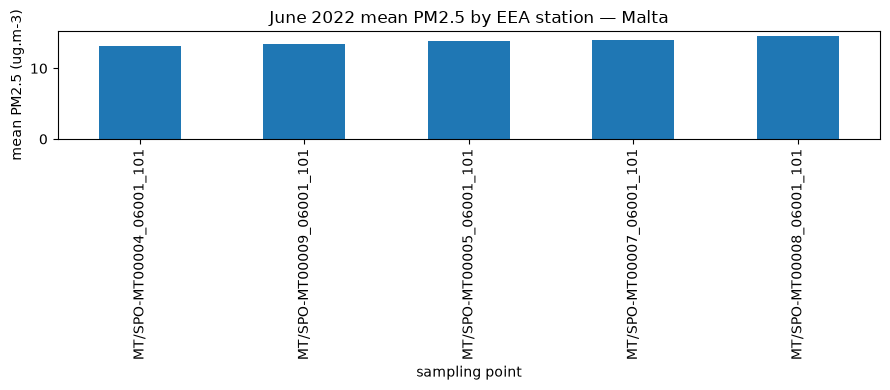

In [6]:
if df is not None and not df.empty:
    means = df.groupby("station_id")["value"].mean().sort_values()
    fig, ax = plt.subplots(figsize=(9, 4))
    means.plot.bar(ax=ax)
    ax.set_ylabel("mean PM2.5 (ug.m-3)")
    ax.set_xlabel("sampling point")
    ax.set_title("June 2022 mean PM2.5 by EEA station — Malta")
    fig.tight_layout()
    plt.show()